In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import datetime as dt
import sys, os
from sklearn.model_selection import train_test_split

%config InlineBackend.figure_format = "retina"

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.0.2


In [2]:
az.style.use("seaborn")
dt.datetime.now()

datetime.datetime(2023, 2, 23, 17, 21, 43, 530125)

In [3]:
RANDOM_SEED = 749195
rng = np.random.default_rng(RANDOM_SEED)
np.set_printoptions(2)
sys.stderr = open(os.devnull, "w")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [rate]
>NUTS: [sigma, weights, noise]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [rate]
>NUTS: [sigma, weights, noise]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [rate]
>NUTS: [sigma, weights, noise]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 70 seconds.
Sampling: [rate, y_observed]
Sampling: [rate, y_observed]


In [4]:
data = pd.read_csv("./data/databricks_cost_data/explorer-cost-graph-2023-02-08.csv", index_col=0).T
data.columns.name = "cluster_name"
data.index = pd.to_datetime(data.index)
data.index.name = "date"

In [18]:
tidy = data.stack().reset_index()
tidy.columns = ["date", "cluster_name", "cost"]
tidy = tidy.assign(cluster_name=lambda df: df.cluster_name.str.extract("(.*)(_su_cluster_spark3.*|-cluster)").loc[:, 0])
tidy = tidy.assign(week_day=lambda df: df.date.dt.weekday)
tidy = tidy.assign(is_su_cluster=lambda df: df.cluster_name.str.contains('su_cluster').astype(int))
tidy = tidy.assign(days_since=lambda df: (df.date - df.date.min()).dt.total_seconds() / (24 * 3600))
tidy = tidy.join(pd.get_dummies(tidy.cluster_name))
tidy.head()

,date,cluster_name,cost,week_day,is_su_cluster,days_since,axp-bu,carolina_calegare,christian_chinem,gabriela_marcon,jaqueline_barbosa,kellen_guimaraes,larissa_liete,lucas_bessa,marco_soares,mariana_andrade,rafael_calsaverini,sofia_garcia,thais_almeida
0,2022-09-01,axp-bu,0.00,3,0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2022-09-01,carolina_calegare,72.68,3,0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,2022-09-01,christian_chinem,0.00,3,0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,2022-09-01,christian_chinem,0.00,3,0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,2022-09-01,christian_chinem,0.00,3,0,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [26]:
FEATURES = tidy.cluster_name.unique().tolist() + ["week_day", "is_su_cluster"]
DATE_TREATMENT = ["days_since"]
TARGET = ["cost"]
T = tidy.loc[:, DATE_TREATMENT].values[:, 0]
X_train = tidy.loc[:, FEATURES].values
Y_train = tidy.loc[:, TARGET].values[:, 0]



In [37]:
with pm.Model() as model:
    X = pm.MutableData("X", X_train.astype(float))
    rate = pmb.BART("rate", X, Y)
    sigma = pm.Exponential("sigma", 1 / 10.)
    w = pm.Normal("weights", mu=0, sigma=sigma)
    noise = pm.Gamma("noise", alpha=2, beta=1)
    y = pm.Normal("y_observed", mu=T * w + rate, sigma=noise, observed=Y)
    idata = pm.sample(random_seed=RANDOM_SEED)


<AxesSubplot:title={'center':'noise'}>

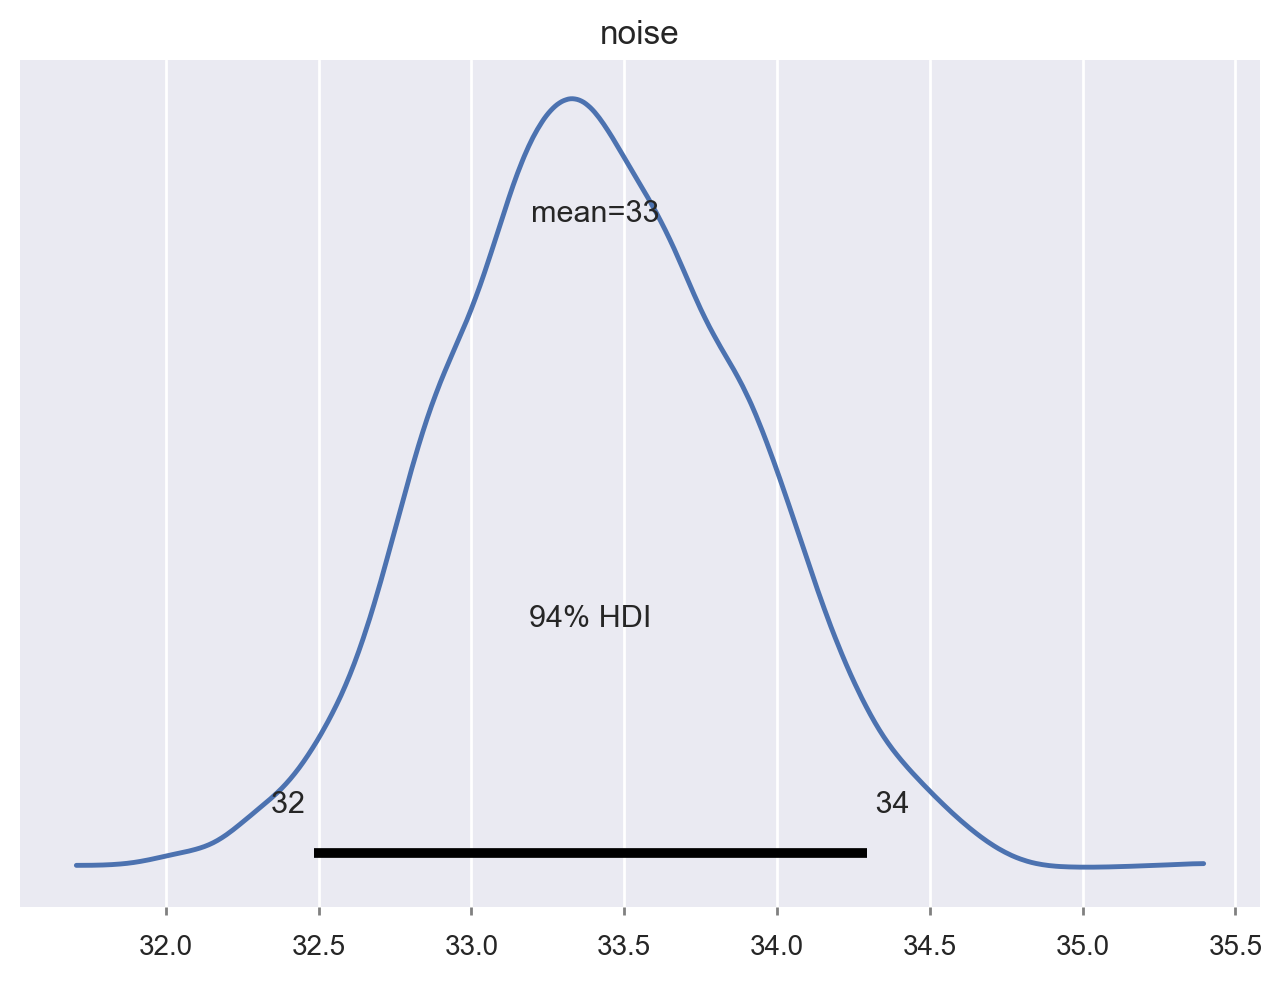

In [38]:
az.plot_posterior(idata, var_names=["noise"])

<AxesSubplot:title={'center':'weights'}>

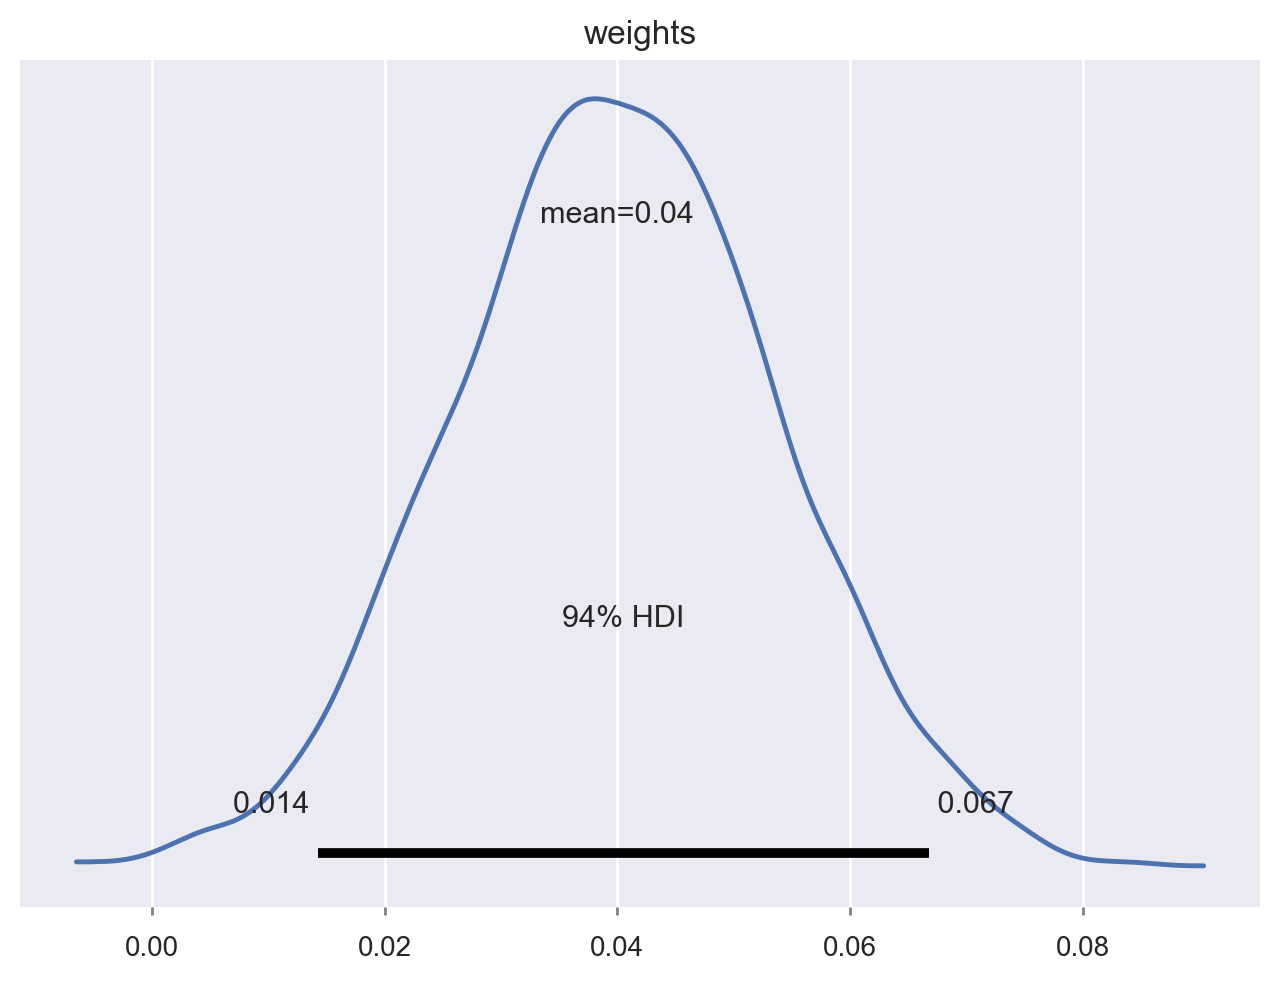

In [39]:
az.plot_posterior(idata, var_names=["weights"])

In [42]:
X_pred = np.zeros((2385, len(FEATURES))).astype(float)
X_pred[:, 0] = 1
X_pred[0:7, 13] = range(7)

In [44]:
with model:
    X.set_value(X_pred)
    predictive_posterior = pm.sample_posterior_predictive(
        trace=idata, random_seed=RANDOM_SEED
    )

In [57]:
predictive_posterior.posterior_predictive["y_observed"].sel(chain=0).to_pandas()

y_observed_dim_2,0,1,2,3,4,5,6,7,8,9,...,2375,2376,2377,2378,2379,2380,2381,2382,2383,2384
draw,,,,,,,,,,,,,,,,,,,,,
0,65.356756,106.758038,22.501651,30.903306,38.765884,33.853797,19.976650,14.032765,79.789027,39.887696,...,38.693583,52.237541,44.558534,39.642208,69.642190,50.142427,104.066473,58.310889,46.148961,61.383896
1,46.782350,42.865065,43.863309,41.231814,62.941196,48.347047,-25.980100,29.495676,15.131379,51.058405,...,29.542253,-1.147965,35.634389,72.889122,40.743957,41.796704,95.879364,46.935149,69.239418,44.590490
2,76.506256,62.997236,45.913054,75.063340,60.442651,44.380219,-34.003358,89.574877,82.233738,55.401089,...,109.624327,65.552315,23.734691,84.491034,20.829552,78.467110,15.526773,64.576902,35.195791,52.903931
3,34.012031,42.427187,43.493021,54.483735,-14.361894,1.593624,24.767788,45.113021,0.784379,13.626214,...,66.187668,9.601490,46.787244,60.635657,71.216363,116.267193,105.176633,55.113085,64.900452,33.068176
4,50.706938,48.377562,80.202605,33.836801,1.777543,32.126354,64.365594,15.935847,46.039261,72.624640,...,4.785105,82.247939,67.960923,63.492946,37.950405,60.820178,24.573517,73.274773,73.447485,99.718069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,72.608141,90.816614,42.074851,66.597946,44.136924,27.967756,-8.621534,42.610502,27.695053,129.392590,...,55.854760,41.492153,28.225463,94.269618,-21.084219,23.291027,33.899440,26.708973,96.530729,101.435706
996,53.485506,88.668981,45.659822,59.636024,1.738612,-21.847776,-18.661388,55.006853,47.517207,56.424201,...,12.689588,70.893574,48.566601,57.256947,44.885580,87.725322,115.778149,6.769209,65.086701,40.206668
997,77.190764,68.621668,93.625082,35.124776,38.631652,63.033351,-46.964688,26.948759,88.771434,30.154178,...,-14.759171,80.572968,40.833185,8.831231,57.826327,-0.350919,30.671867,36.972366,86.897836,62.728597
